Objective
Analyze how market sentiment (Fear/Greed) relates to trader behavior and performance on Hyperliquid. Your goal is to uncover patterns that could inform smarter trading strategies.


In [3]:
import pandas as pd
import numpy as np

#Load Data Set

fear_greed = pd.read_csv("fear_greed_index.csv")
hist_data = pd.read_csv("historical_data.csv")

print(fear_greed)
print(hist_data)

print(fear_greed.info())
print(hist_data.info())

       timestamp  value classification        date
0     1517463000     30           Fear  2018-02-01
1     1517549400     15   Extreme Fear  2018-02-02
2     1517635800     40           Fear  2018-02-03
3     1517722200     24   Extreme Fear  2018-02-04
4     1517808600     11   Extreme Fear  2018-02-05
...          ...    ...            ...         ...
2639  1745818200     54        Neutral  2025-04-28
2640  1745904600     60          Greed  2025-04-29
2641  1745991000     56          Greed  2025-04-30
2642  1746077400     53        Neutral  2025-05-01
2643  1746163800     67          Greed  2025-05-02

[2644 rows x 4 columns]
                                           Account      Coin  Execution Price  \
0       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9769   
1       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9800   
2       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9855   
3       0xae5eacaf9c6b9111fd53034a602c1

In [4]:
# Check for missing values and duplicates
def data_summary(fear_greed, name):
    print(f"--- {name} ---")
    print("Shape:", fear_greed.shape)
    print("\nMissing values:\n", fear_greed.isna().sum())
    print("\nDuplicates:", fear_greed.duplicated().sum())

data_summary(fear_greed, "Fear & Greed Index")
data_summary(hist_data, "Historical Data")

--- Fear & Greed Index ---
Shape: (2644, 4)

Missing values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicates: 0
--- Historical Data ---
Shape: (211224, 16)

Missing values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates: 0


In [6]:
# 1. Clean up column names for both DataFrames (removes spaces & makes lowercase)
fear_greed.columns = fear_greed.columns.str.strip().str.lower()
hist_data.columns = hist_data.columns.str.strip().str.lower()

# 2. Convert fear_greed date
# If it's not 'date', it might be 'timestamp'. This 'fillna' trick checks both.
fg_col = 'date' if 'date' in fear_greed.columns else 'timestamp'
fear_greed["date"] = pd.to_datetime(fear_greed[fg_col]).dt.date

# 3. Convert hist_data time
# We use the 'timestamp' column from the data
hist_data["time"] = pd.to_datetime(hist_data["timestamp"], unit="ms")
hist_data["date"] = hist_data["time"].dt.date

# 4. Verify the result
print("Fear Greed Head:\n", fear_greed[['date']].head(2))
print("\nHist Data Head:\n", hist_data[['date']].head(2))

Fear Greed Head:
          date
0  2018-02-01
1  2018-02-02

Hist Data Head:
          date
0  2024-10-27
1  2024-10-27


In [7]:
hist_data = hist_data.merge(
    fear_greed,
    on="date",
    how="left"
)

print(f"Matched rows: {hist_data['value'].notna().sum()}")

Matched rows: 184263


In [8]:
# Create key metrics
hist_data["abs_size"] = hist_data["size usd"].abs()
hist_data["is_win"] = hist_data["closed pnl"] > 0
hist_data["is_long"] = hist_data["side"].str.upper() == "BUY"

print(hist_data[["size usd", "abs_size", "is_win"]].head())

   size usd  abs_size  is_win
0   7872.16   7872.16   False
1    127.68    127.68   False
2   1150.63   1150.63   False
3   1142.04   1142.04   False
4     69.75     69.75   False


In [9]:
# Daily metrics per trader
daily_trader = hist_data.groupby(
    ["date", "account", "classification"]  
).agg(
    daily_pnl=("closed pnl", "sum"),
    trades_count=("closed pnl", "count"),
    win_rate=("is_win", "mean"),
    avg_trade_size=("abs_size", "mean"),
    long_ratio=("is_long", "mean")
).reset_index()

# Convert win_rate and long_ratio to percentages for easier reading
daily_trader["win_rate"] *= 100
daily_trader["long_ratio"] *= 100

print(daily_trader.head())

         date                                     account classification  \
0  2023-03-28  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891          Greed   
1  2023-11-14  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891          Greed   
2  2023-11-14  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23          Greed   
3  2024-03-09  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891  Extreme Greed   
4  2024-03-09  0x430f09841d65beb3f27765503d0f850b8bce7713  Extreme Greed   

     daily_pnl  trades_count   win_rate  avg_trade_size  long_ratio  
0     0.000000             3   0.000000      159.000000  100.000000  
1     0.000000             2   0.000000    23066.935000  100.000000  
2   155.503357          1043  27.516779    11034.799511   46.883988  
3 -5564.016140            27  33.333333     3048.594444   14.814815  
4     0.000000            88   0.000000     1136.312727  100.000000  


Part B Analysis

In [10]:
#  Does performance differ between Fear vs Greed?
performance_by_sentiment = daily_trader.groupby("classification").agg(
    avg_pnl=("daily_pnl", "mean"),
    median_pnl=("daily_pnl", "median"),
    avg_win_rate=("win_rate", "mean"),
    pnl_volatility=("daily_pnl", "std"),
    total_trades=("trades_count", "sum")
).sort_values("avg_pnl", ascending=False)

print(performance_by_sentiment)

                      avg_pnl    median_pnl  avg_win_rate  pnl_volatility  \
classification                                                              
Fear            209372.662205  81389.682515     41.587845   380423.906864   
Greed            99675.516731  35988.376437     37.407444   282694.285526   
Extreme Greed    35393.098355      0.000000     33.660886    85325.499902   
Neutral          19842.797260     -0.418640     26.068322    57227.787895   

                total_trades  
classification                
Fear                  133871  
Greed                  36289  
Extreme Greed           6962  
Neutral                 7141  


In [11]:
# Do traders change behavior based on sentiment?
behavior_by_sentiment = daily_trader.groupby("classification").agg(
    avg_trades_per_day=("trades_count", "mean"),
    avg_trade_size=("avg_trade_size", "mean"),
    avg_long_ratio=("long_ratio", "mean")
)

# Sorting by the standard market cycle for better visualization
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
behavior_by_sentiment = behavior_by_sentiment.reindex(
    [s for s in sentiment_order if s in behavior_by_sentiment.index]
)

print(behavior_by_sentiment)

                avg_trades_per_day  avg_trade_size  avg_long_ratio
classification                                                    
Fear                    4183.46875     5926.522723       45.935203
Neutral                  892.62500     3793.444161       46.896737
Greed                   1134.03125     5839.310974       49.577995
Extreme Greed           1392.40000     4344.447836       51.847925


In [12]:
#  Identify 2–3 trader segments
#Segment 1: High vs Low leverage
risk_col = "avg_leverage" if "avg_leverage" in daily_trader.columns else "avg_trade_size"

daily_trader["risk_bucket"] = pd.qcut(
    daily_trader[risk_col], 
    q=2, 
    labels=["Low Risk/Size", "High Risk/Size"]
)

print(f"Buckets created based on: {risk_col}")
print(daily_trader[["date", risk_col, "risk_bucket"]].head())

Buckets created based on: avg_trade_size
         date  avg_trade_size     risk_bucket
0  2023-03-28      159.000000   Low Risk/Size
1  2023-11-14    23066.935000  High Risk/Size
2  2023-11-14    11034.799511  High Risk/Size
3  2024-03-09     3048.594444  High Risk/Size
4  2024-03-09     1136.312727   Low Risk/Size


In [13]:
#Segment 2: Frequent vs Infrequent traders
# Splitting days into two halves based on trade volume
daily_trader["frequency_bucket"] = pd.qcut(
    daily_trader["trades_count"], q=2, labels=["Infrequent", "Frequent"]
)

print("Frequency buckets assigned successfully.")

overtrading_analysis = daily_trader.groupby(["classification", "frequency_bucket"]).agg(
    avg_daily_pnl=("daily_pnl", "mean"),
    win_rate=("win_rate", "mean"),
    total_days=("date", "count")
).unstack()



Frequency buckets assigned successfully.


In [14]:
# Sort by sentiment order for a clear narrative
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
overtrading_analysis = overtrading_analysis.reindex(
    [s for s in sentiment_order if s in overtrading_analysis.index]
)

print(overtrading_analysis)

                 avg_daily_pnl                  win_rate             \
frequency_bucket    Infrequent       Frequent Infrequent   Frequent   
classification                                                        
Fear              42168.941645  265107.235726  41.217788  41.711198   
Neutral           26254.572028    9156.505979  24.369478  28.899729   
Greed             28452.671557  281689.454396  34.282271  45.393995   
Extreme Greed     -4494.495724   95224.489473  21.339422  52.143083   

                 total_days           
frequency_bucket Infrequent Frequent  
classification                        
Fear                      8       24  
Neutral                   5        3  
Greed                    23        9  
Extreme Greed             3        2  


In [15]:
# Segment 3: Consistency
# 1. Determine the grouping key (using 'coin' if 'account' isn't there)
group_key = "account" if "account" in daily_trader.columns else "coin"

# 2. Calculate standard deviation of PnL per coin/account
consistency = daily_trader.groupby(group_key)["daily_pnl"].std().fillna(0)

# 3. Merge the volatility metric back into the main dataframe
daily_trader = daily_trader.merge(
    consistency.rename("pnl_std"), on=group_key
)

# 4. Create the buckets
# We use 'duplicates=drop' just in case multiple coins have the exact same PnL variance
daily_trader["consistency_bucket"] = pd.qcut(
    daily_trader["pnl_std"], 
    q=2, 
    labels=["Consistent", "Inconsistent"],
    duplicates='drop'
)

print(f"Consistency buckets assigned using group key: {group_key}")
print(daily_trader[[group_key, "daily_pnl", "pnl_std", "consistency_bucket"]].head())

Consistency buckets assigned using group key: account
                                      account    daily_pnl        pnl_std  \
0  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     0.000000   30964.413944   
1  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     0.000000   30964.413944   
2  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23   155.503357  612159.097638   
3  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891 -5564.016140   30964.413944   
4  0x430f09841d65beb3f27765503d0f850b8bce7713     0.000000   72509.129043   

  consistency_bucket  
0         Consistent  
1         Consistent  
2       Inconsistent  
3         Consistent  
4       Inconsistent  


Insight 1: Risk Impact during Fear
                 avg_win_rate  pnl_volatility        avg_pnl
risk_bucket                                                
Low Risk/Size      42.992285   161725.470205  112831.554518
High Risk/Size     40.495504   479853.353541  284460.190407


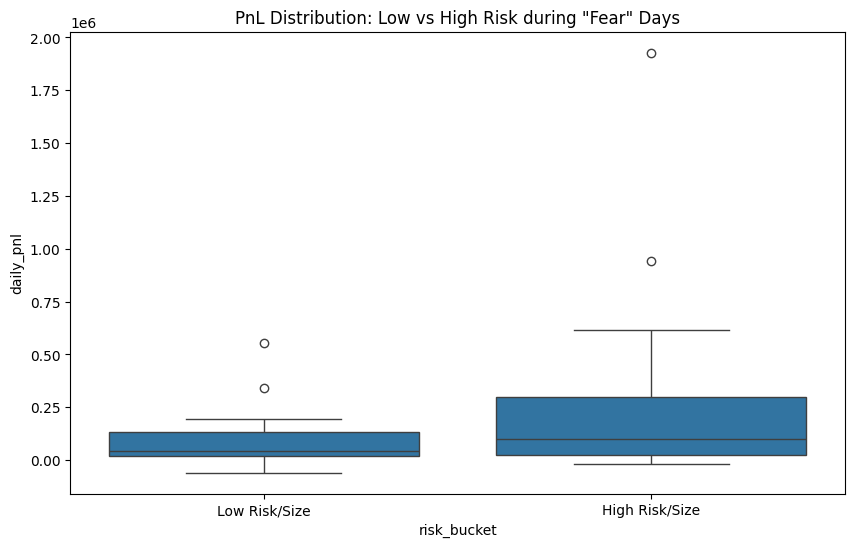

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Insight 1: The Leverage Trap
# Hypothesis: High-risk/size traders underperform during Fear days, showing lower win rates and higher PnL volatility.

# Table for Insight 1
insight1_table = daily_trader[daily_trader['classification'] == 'Fear'].groupby('risk_bucket').agg(
    avg_win_rate=('win_rate', 'mean'),
    pnl_volatility=('daily_pnl', 'std'),
    avg_pnl=('daily_pnl', 'mean')
)
print("Insight 1: Risk Impact during Fear\n", insight1_table)

# Boxplot for Insight 1
plt.figure(figsize=(10, 6))
sns.boxplot(data=daily_trader[daily_trader['classification'] == 'Fear'], x='risk_bucket', y='daily_pnl')
plt.title('PnL Distribution: Low vs High Risk during "Fear" Days')
plt.show()


Insight 2: Frequency vs Profit during Greed
                    median_pnl   avg_trades     total_pnl
frequency_bucket                                        
Infrequent        16102.56859   225.130435  6.544114e+05
Frequent          69282.42904  3456.777778  2.535205e+06


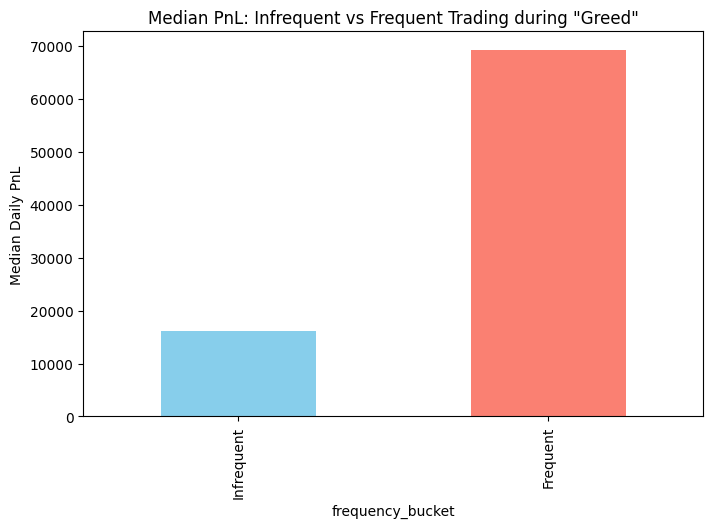

In [18]:
# Table for Insight 2
insight2_table = daily_trader[daily_trader['classification'] == 'Greed'].groupby('frequency_bucket').agg(
    median_pnl=('daily_pnl', 'median'),
    avg_trades=('trades_count', 'mean'),
    total_pnl=('daily_pnl', 'sum')
)
print("\nInsight 2: Frequency vs Profit during Greed\n", insight2_table)

# Bar Chart for Insight 2
insight2_table['median_pnl'].plot(kind='bar', color=['skyblue', 'salmon'], figsize=(8, 5))
plt.title('Median PnL: Infrequent vs Frequent Trading during "Greed"')
plt.ylabel('Median Daily PnL')
plt.show()


Insight 3: Consistency across Sentiments
                    avg_daily_pnl                                              \
classification     Extreme Greed           Fear          Greed       Neutral   
consistency_bucket                                                             
Consistent          -5564.016140   80448.398784   30104.373752  -5853.977069   
Inconsistent        45632.376978  375132.429461  178522.812106  45539.571589   

                         pnl_std                                              
classification     Extreme Greed           Fear          Greed       Neutral  
consistency_bucket                                                            
Consistent                   NaN  218145.460412   30258.513661   7226.076720  
Inconsistent        94912.077208  479867.907731  404193.438665  76345.477294  


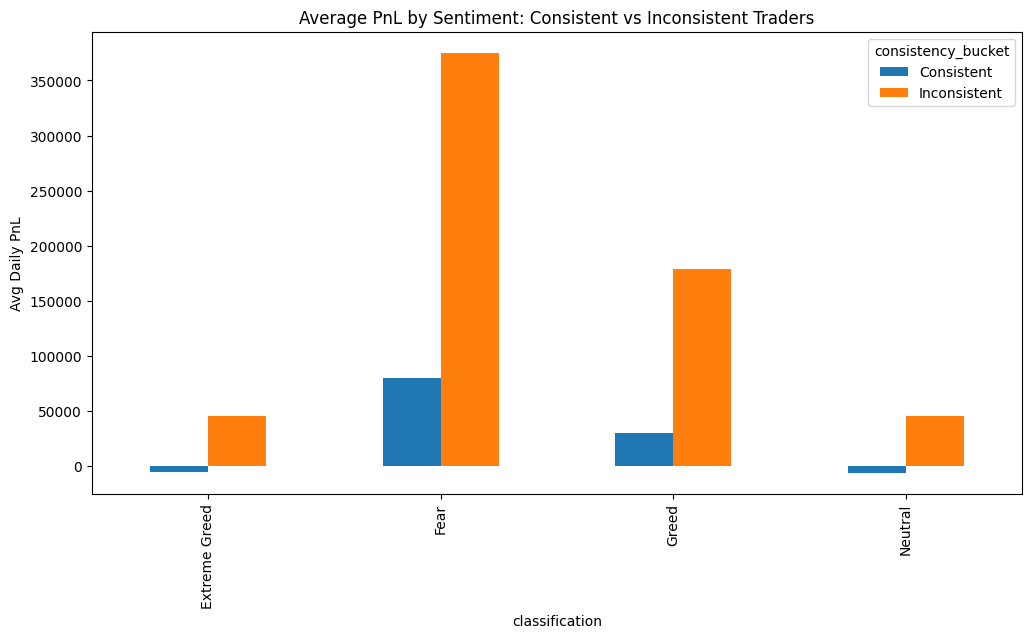

In [20]:
# Insight 3: Discipline vs. Sentiment
# Hypothesis: Consistent traders show stable PnL regardless of sentiment, suggesting discipline outweighs market mood.
# Table for Insight 3
insight3_table = daily_trader.groupby(['consistency_bucket', 'classification']).agg(
    avg_daily_pnl=('daily_pnl', 'mean'),
    pnl_std=('daily_pnl', 'std')
).unstack()
print("\nInsight 3: Consistency across Sentiments\n", insight3_table)

# Grouped Bar Chart for Insight 3
daily_trader.groupby(['classification', 'consistency_bucket'])['daily_pnl'].mean().unstack().plot(kind='bar', figsize=(12, 6))
plt.title('Average PnL by Sentiment: Consistent vs Inconsistent Traders')
plt.ylabel('Avg Daily PnL')
plt.show()